In [1]:
# ============================================================
# MODULO 3 — MOTIFS & DISCORDS (Matrix Profile con STUMPY)
# canale enmo, finestra w=16 (~8h, 16 step da 30min)
# ============================================================
import gzip, pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import stumpy

with gzip.open("CMI_timeseries_dataset.pkl.gz", "rb") as f:
    CMI = pickle.load(f)

X = np.vstack([ts["enmo"].values for ts in CMI])
df = pd.DataFrame(X, columns=[str(i) for i in range(X.shape[1])])
df["sii_binary"] = [ts["sii_binary"].iloc[0] for ts in CMI]
tcols = [str(i) for i in range(X.shape[1])]

# z-score per serie (confronta la forma, non l'ampiezza)
ts_scaled = df[tcols].sub(df[tcols].mean(axis=1), axis=0).div(df[tcols].std(axis=1)+1e-9, axis=0)

In [3]:
# ── Scelta di una serie di esempio "attiva" ──────────────────
# Prendo una serie ad alta varianza: le serie a caso sono spesso
# dominate da inattivita' (tanti zeri), e i motif risulterebbero
# segmenti piatti poco interessanti.
variances = ts_scaled.var(axis=1)
example_idx = variances.sort_values(ascending=False).index[10]

s = ts_scaled.loc[example_idx, tcols].values.astype(float)
w = 16   # finestra: 16 step x 30min = 8 ore

# ── Matrix profile (STUMPY) ──────────────────────────────────
# Il matrix profile misura, per ogni posizione, la distanza dalla
# sottosequenza piu' simile altrove nella serie:
#   valore BASSO -> pattern che si RIPETE (motif)
#   valore ALTO  -> pattern UNICO/anomalo (discord)
mp = stumpy.stump(s, m=w)
profile = mp[:, 0].astype(float)

motif_idx   = np.argsort(profile)[0]      # minimo -> motif
nn_idx      = int(mp[motif_idx, 1])       # il suo gemello
discord_idx = np.argsort(profile)[-1]     # massimo -> discord

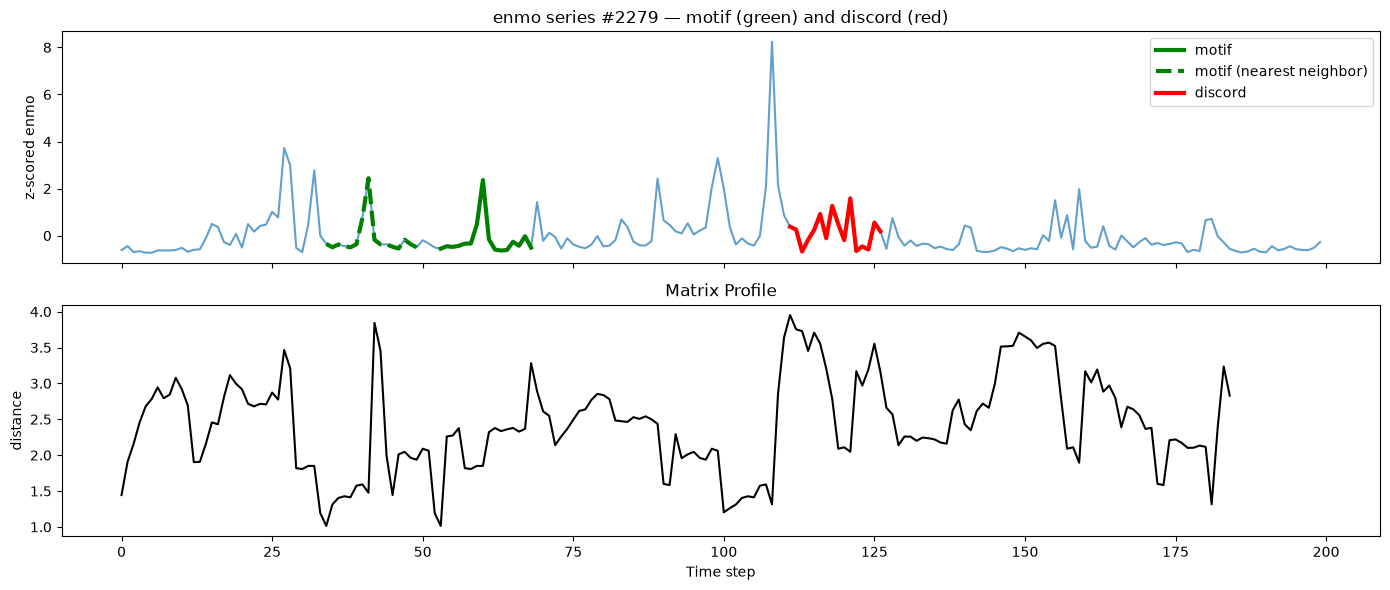

In [5]:
# ── Visualizzazione: serie + motif + discord + matrix profile ──
fig, ax = plt.subplots(2, 1, figsize=(14, 6), sharex=True)

ax[0].plot(s, color='C0', alpha=0.7)
ax[0].plot(range(motif_idx, motif_idx+w), s[motif_idx:motif_idx+w], color='g', lw=3, label='motif')
ax[0].plot(range(nn_idx, nn_idx+w), s[nn_idx:nn_idx+w], color='g', lw=3, ls='--', label='motif (nearest neighbor)')
ax[0].plot(range(discord_idx, discord_idx+w), s[discord_idx:discord_idx+w], color='r', lw=3, label='discord')
ax[0].set_title(f'enmo series #{example_idx} — motif (green) and discord (red)')
ax[0].set_ylabel('z-scored enmo'); ax[0].legend()

ax[1].plot(profile, color='k')
ax[1].set_title('Matrix Profile'); ax[1].set_xlabel('Time step'); ax[1].set_ylabel('distance')
plt.tight_layout()
plt.savefig('ts_matrix_profile_single.png', dpi=300, bbox_inches='tight')
plt.show()

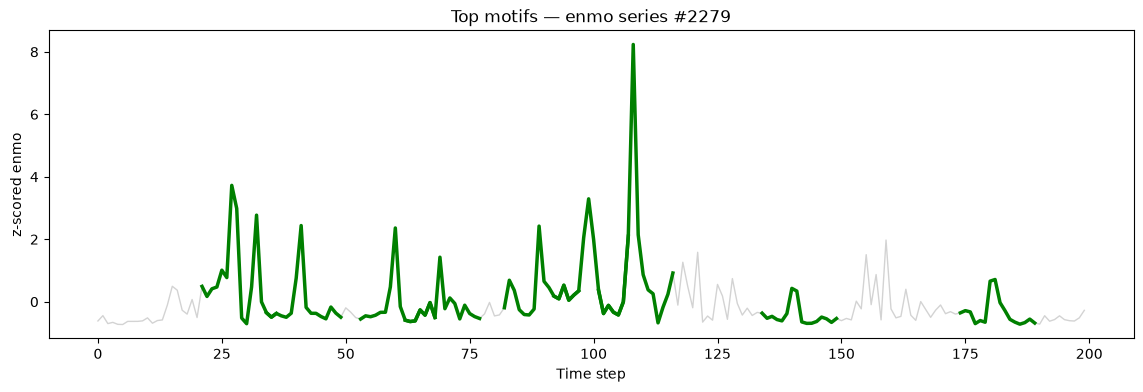

In [7]:
# ── Motif multipli su una serie (stumpy.motifs) ──────────────
# Trova i pattern ricorrenti piu' forti. Il filtro min_std nel profilo
# neutralizza i segmenti piatti (inattivita'/sonno), che altrimenti
# dominerebbero come "pattern piu' ripetuto" ma non sono informativi.
prof = profile.copy()
for i in range(len(prof)):
    if np.std(s[i:i+w]) < 0.05:      # segmento quasi-piatto
        prof[i] = np.inf

motif_dist, motif_indices = stumpy.motifs(s, prof, max_motifs=3, min_neighbors=1)

plt.figure(figsize=(14, 4))
plt.plot(s, color='lightgrey', lw=1)
colors = ['g', 'b', 'm']
for row, c in zip(motif_indices, colors):
    for pos in row:
        if pos >= 0:
            plt.plot(range(pos, pos+w), s[pos:pos+w], color=c, lw=2.5)
plt.title(f"Top motifs — enmo series #{example_idx}")
plt.xlabel("Time step"); plt.ylabel("z-scored enmo")
plt.savefig('ts_motifs_multiple.png', dpi=300, bbox_inches='tight')
plt.show()

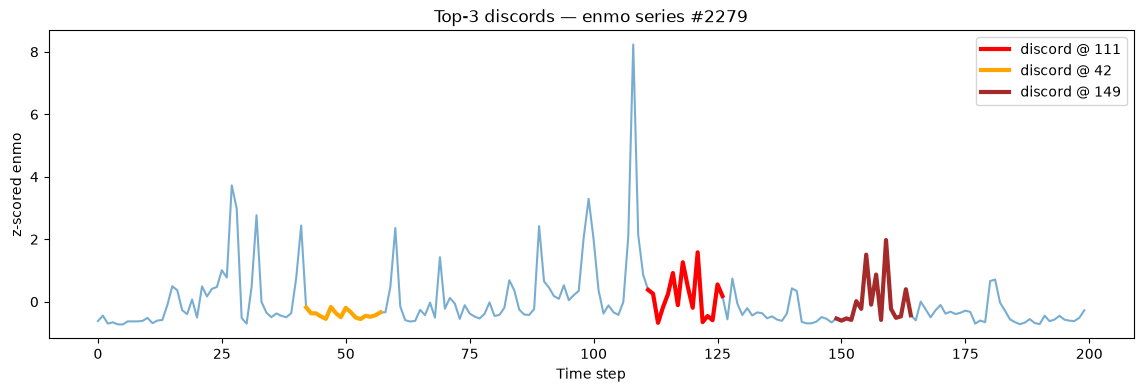

In [8]:
# ── Discords: le 3 sottosequenze piu' anomale ────────────────
# Prendo i 3 valori piu' alti del profilo, con "exclusion zone" per
# evitare che i 3 discord siano tutti vicini/sovrapposti.
def top_discords(profile, w, k=3, ex_zone=None):
    if ex_zone is None: ex_zone = w // 2
    prof = profile.copy()
    found = []
    for _ in range(k):
        idx = int(np.argmax(prof))
        found.append(idx)
        lo, hi = max(0, idx-ex_zone), min(len(prof), idx+ex_zone)
        prof[lo:hi] = -np.inf   # azzera l'intorno per il prossimo giro
    return found

discords = top_discords(profile, w, k=3)

plt.figure(figsize=(14, 4))
plt.plot(s, color='C0', alpha=0.6)
for a, c in zip(discords, ['r', 'orange', 'brown']):
    plt.plot(range(a, a+w), s[a:a+w], color=c, lw=3, label=f'discord @ {a}')
plt.title(f"Top-3 discords — enmo series #{example_idx}")
plt.xlabel("Time step"); plt.ylabel("z-scored enmo"); plt.legend()
plt.savefig('ts_discords.png', dpi=300, bbox_inches='tight')
plt.show()